## Library

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # OpenMP 충돌 방지 (sklearn n_jobs=-1 + torch 동시 사용)
import torch 

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from scipy.stats import mannwhitneyu
from sklearn.svm import OneClassSVM
from psmpy.functions import cohenD
from psmpy.plotting import *
from psmpy import PsmPy
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import set_matplotlib_hangul # 한글 폰트 변환
warnings.filterwarnings('ignore')

Hangul OK in your MAC!


## Data Load
- 데이터 출처:  [[캐글]PUBG Finish Placement Prediction](https://www.kaggle.com/competitions/pubg-finish-placement-prediction/data)

In [2]:
# Load Data
df = pd.read_csv('../data/train_V2.csv')
df

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.000,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.040,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.000,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.000,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.000,0,0,49.75,2,0,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,...,0,1292.0000,0,0.000,0,0,1019.00,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,...,0,0.0000,0,0.000,0,0,81.70,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,...,0,0.0000,0,2.184,0,0,788.70,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,4,180.40,1,1,2,11,...,2,0.0000,0,0.000,0,0,2748.00,8,0,0.8000


## Data Summary

|변수|데이터 유형|데이터 설명|
|---|:---|:---|
|assists|int|자신에게 사살되지 못했지만 데미지를 넣은 적의 수|
|boosts|int|도핑 아이템 사용 횟수|
|damageDealt|float|적에게 가한 전체 대미지|
|DBNOs|int|기절시킨 적의 수|
|groupId|object|경기내 식별 ID|
|headshotKills|int|헤드샷으로 죽인 적의 수|
|heals|int|회복 아이템 사용 횟수|
|Id|object|해당 데이터 ID|
|killPlace|int|경기 내 죽인 적의 순위|
|killPoints|int|유저의 레이팅|
|kills|int|경기 내 적을 죽인 수|
|killStreaks|int|짧은 시간 내에 연속으로 적을 죽인 수|
|longestKill|float|사살한 적까지의 거리 최대값|
|matchDuration|int|경기가 진행된 시간 (단위: 초)|
|matchId|object|경기 식별 ID|
|matchType|object|경기 모드(솔로, 듀오, 스쿼드...)|
|numGroups|int|경기 내 참여 그룹 수|
|rankPoints|int|유저의 레이팅|
|revives|int|유저가 팀원을 부활시킨 횟수|
|rideDistance|float|이동수단을 통해 이동한 거리(단위: m)|
|roadKills|int|이동수단으로 살해한 적의 수|
|swimDistance|float|수영으로 이동한 거리(단위: m)|
|teamKills|int|같은 팀원을 살해한 수|
|vehicleDestroys|int|파괴한 이동수단의 수|
|walkDistance|float|걸어서 이동한 거리(단위: m)|
|weaponsAcquired|int|획득한 무기의 수|
|winPoints|int|유저의 ELO레이팅(승리 횟수 기반)|
|winPlacePerc|float|현재 경기에서의 백분위 기반 유저의 순위(종속변수)|

## Data Preprocessing

In [3]:
# Check Data Type
def Check_Data_Type(df, return_data=False):
    df_str = df.select_dtypes(include=['object'])
    df_num = df.select_dtypes(include=['number'])

    print(f"Object Type Length: {df_str.shape[1]}")
    print(f"Num Type Length: {df_num.shape[1]}")

    if return_data: # 출력만 보려할 때
        return df_str, df_num

In [4]:
df.info()
print()
Check_Data_Type(df)

<class 'pandas.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               str    
 1   groupId          str    
 2   matchId          str    
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        str    
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints        int64 

In [5]:
# 불필요한 컬럼 제거
df.drop(columns={'matchId', 'numGroups', 'maxPlace', 'killPlace', 'matchDuration',
                 'vehicleDestroys', 'killPoints', 'winPoints'}, inplace=True)
df.head()

,Id,groupId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,kills,killStreaks,...,matchType,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,walkDistance,weaponsAcquired,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,0,0,0.00,0,0,0,0,0,...,squad-fpp,-1,0,0.0000,0,0.00,0,244.80,1,0.4444
1,eef90569b9d03c,684d5656442f9e,0,0,91.47,0,0,0,0,0,...,squad-fpp,1484,0,0.0045,0,11.04,0,1434.00,5,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,1,0,68.00,0,0,0,0,0,...,duo,1491,0,0.0000,0,0.00,0,161.80,2,0.7755
3,4616d365dd2853,a930a9c79cd721,0,0,32.90,0,0,0,0,0,...,squad-fpp,1408,0,0.0000,0,0.00,0,202.70,3,0.1667
4,315c96c26c9aac,de04010b3458dd,0,0,100.00,0,0,0,1,1,...,solo-fpp,1560,0,0.0000,0,0.00,0,49.75,2,0.1875


In [6]:
# 위 'rankPoints' 값에 -1을 조회
rank = df[df['rankPoints'] == -1]
len(rank)

1701810

In [7]:
# rankPoints의 -1을 제거하기엔 데이터 손실이 크기에 0으로 대체
df['rankPoints'] = df['rankPoints'].replace(-1, 0)
df.isna().sum() # 결측치 확인

Id                 0
groupId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
kills              0
killStreaks        0
longestKill        0
matchType          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
walkDistance       0
weaponsAcquired    0
winPlacePerc       1
dtype: int64

In [8]:
# 파생변수 생성
df['total_distance'] = df['walkDistance'] + df['rideDistance'] + df['swimDistance'] # 총 이동거리
df['headshot_Rate'] = df['headshotKills'] / df['kills'].replace(0, np.inf) # 킬 수 대비 헤드샷 비율 계산
df['kills_per_distance'] = df['total_distance'] / df['kills'].replace(0, np.inf) # 킬 수 대비 이동거리

df = df.dropna(subset=['winPlacePerc']) # 결측치 제거
df.head()

,Id,groupId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,kills,killStreaks,...,rideDistance,roadKills,swimDistance,teamKills,walkDistance,weaponsAcquired,winPlacePerc,total_distance,headshot_Rate,kills_per_distance
0,7f96b2f878858a,4d4b580de459be,0,0,0.00,0,0,0,0,0,...,0.0000,0,0.00,0,244.80,1,0.4444,244.8000,0.0,0.00
1,eef90569b9d03c,684d5656442f9e,0,0,91.47,0,0,0,0,0,...,0.0045,0,11.04,0,1434.00,5,0.6400,1445.0445,0.0,0.00
2,1eaf90ac73de72,6a4a42c3245a74,1,0,68.00,0,0,0,0,0,...,0.0000,0,0.00,0,161.80,2,0.7755,161.8000,0.0,0.00
3,4616d365dd2853,a930a9c79cd721,0,0,32.90,0,0,0,0,0,...,0.0000,0,0.00,0,202.70,3,0.1667,202.7000,0.0,0.00
4,315c96c26c9aac,de04010b3458dd,0,0,100.00,0,0,0,1,1,...,0.0000,0,0.00,0,49.75,2,0.1875,49.7500,0.0,49.75


## EDA

In [9]:
# boxplot
def box_plot(winner, loser, col):
    fig, axes = plt.subplots(1, 2, figsize=(8, 6))
    sns.boxplot(ax=axes[0], y=winner[col])
    axes[0].set_title('Winner', fontsize=15)
    sns.boxplot(ax=axes[1], y=loser[col], color='orange')
    axes[1].set_title('Loser', fontsize=15)
    plt.tight_layout()
    plt.show()
    print(f"승리유저 평균 {col}: {winner[col].mean():.2f}")
    print(f"패배유저 평균 {col}: {loser[col].mean():.2f}")

# histplot
def hist_plot(df1, col, df2=None, figsize=(8, 6), bins=30, alpha=0.6, color1='skyblue', color2='salmon', label1=None, label2=None, title=None):
        plt.figure(figsize=figsize)

        # 개별 데이터 프레임
        sns.histplot(df1[col], kde=True, bins=bins, alpha=alpha, color=color1, label=label1 if label1 else ('Group 1' if df2 is not None else None))
        
        if df2 is not None: # 두 그룹 비교
            sns.histplot(df2[col], kde=True, bins=bins, alpha=alpha, color=color2, label=label2 if label2 else 'Group 2')
            plt.legend()  # 두 그룹일 때만 범례 표시

        plt.title(title if title else f'{col} Distribution (Histogram + KDE)')
        plt.xlabel(col)
        plt.show() 

# heatmap
def heatmap(df, figsize=(10, 6), target_col=None, threshold=0.4, annot=True, fmt='.2f', cmap='Blues', annot_kws={"size": 12}, cbar=True, title=None):
        corr = df.select_dtypes(include=['number']).corr() # 숫자형 데이터 타입

        if target_col: # 타겟 컬럼과의 상관관계만 추출
            corr = corr[[target_col]].sort_values(by=target_col, ascending=False)
            corr = corr[abs(corr[target_col]) >= threshold].dropna()
            
            title = title or f"'{target_col}'과의 상관관계 (≥ {threshold})"
            plt.figure(figsize=(4, len(corr) * 0.6))
            sns.heatmap(corr.T, annot=annot, fmt=fmt, cmap=cmap, annot_kws=annot_kws, cbar=cbar)
            plt.xticks(fontsize=10)
            plt.yticks(fontsize=10)

        else: # 전체 상관관계 매트릭스
            title = title or "전체 상관관계 히트맵"
            plt.figure(figsize=figsize)
            sns.heatmap(corr, annot=annot, fmt=fmt, cmap=cmap, annot_kws=annot_kws, cbar=cbar)
            plt.xticks(fontsize=10)
            plt.yticks(fontsize=10)

        plt.title(title)
        plt.show()

- 분포 분석

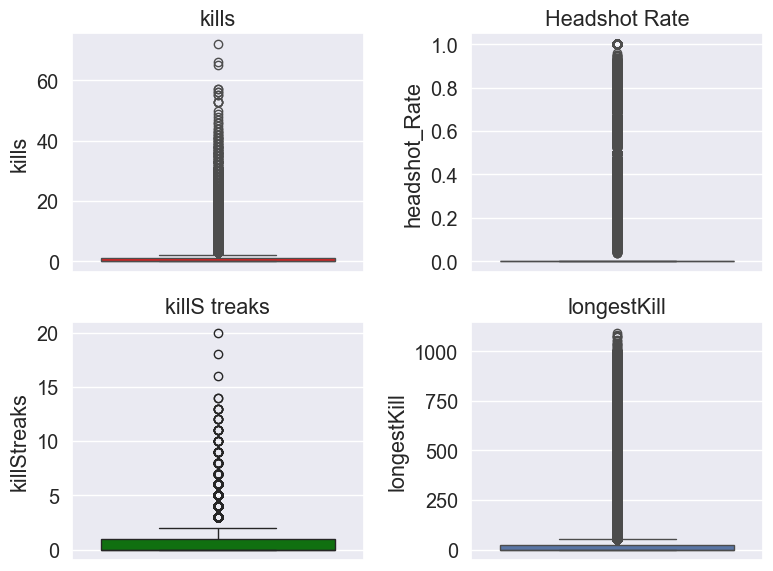

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.boxplot(ax=axes[0, 0], y=df['kills'], color='red') # 킬
axes[0, 0].set_title('kills')
sns.boxplot(ax=axes[0, 1], y=df['headshot_Rate'], color='orange') # 킬 수 대비 헤드샷 비율
axes[0, 1].set_title('Headshot Rate')
sns.boxplot(ax=axes[1, 0], y=df['killStreaks'], color='green') # 연속으로 킬 처치
axes[1, 0].set_title('killS treaks')
sns.boxplot(ax=axes[1, 1], y=df['longestKill']) # 가장 먼 거리에서 킬(킬을 하고 이동을 많이 할 경우 값이 높게 나올 수 있음
axes[1, 1].set_title('longestKill')             # (예: 킬 후 차량, 자전거 탑승을 해서 값이 높게 나올 수도 있다.)
plt.tight_layout()
plt.show()

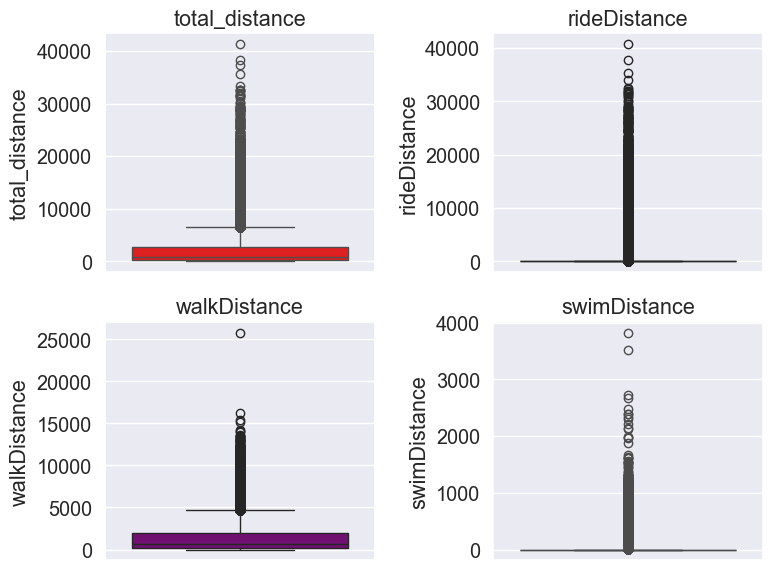

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.boxplot(ax=axes[0, 0], y=df['total_distance'], color='red') # 총 이동거리
axes[0, 0].set_title('total_distance')
sns.boxplot(ax=axes[0, 1], y=df['rideDistance'], color='green') # 자전거 이동거리
axes[0, 1].set_title('rideDistance')
sns.boxplot(ax=axes[1, 0], y=df['walkDistance'], color='purple') # 걸어서 이동거리
axes[1, 0].set_title('walkDistance')
sns.boxplot(ax=axes[1, 1], y=df['swimDistance']) # 수영 이동거리
axes[1, 1].set_title('swimDistance')

plt.tight_layout()
plt.show()

### 승리 점수 분석

- 승리 점수가 높을 수록 핵 사용자와 관계가 있을거 같기에 분포 분석

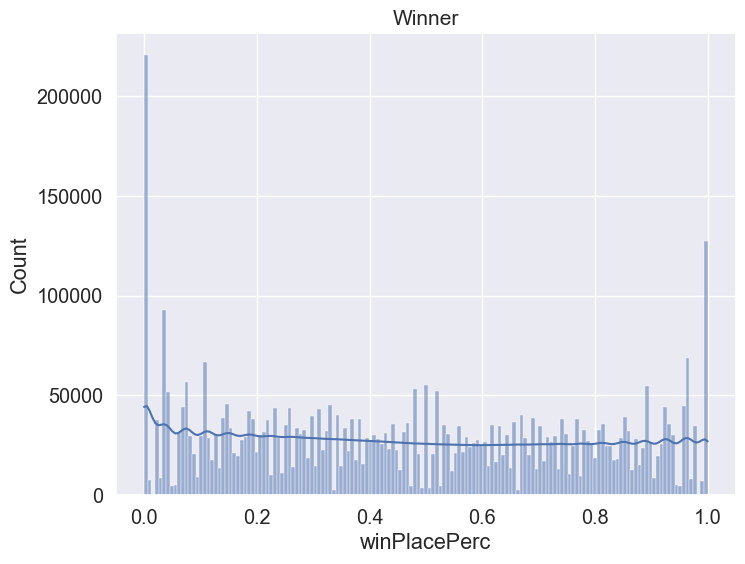

승리 예측 평균 점수: 0.47


In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(df['winPlacePerc'], kde=True)
plt.title('Winner', fontsize=15)
plt.show()

print(f"승리 예측 평균 점수: {df['winPlacePerc'].mean():.2f}")

### 승리 유저 VS 패배 유저 비교
- 승리 유저 : "winPlacePerc" 값이 1인 유저
- 패배 유저 : "winPlacePerc" 값이 1이 아닌 유저
- 두 그룹간 패턴 파악

In [13]:
winner = df[df['winPlacePerc'] == 1]
loser = df[df['winPlacePerc'] != 1]

print(f"전체 유저: {len(df)}")
print(f"패배 유저 비율: {(len(loser) / len(df)) * 100:.2f}%")
print(f"승리 유저 비율: {(len(winner) / len(df)) * 100:.2f}%")

전체 유저: 4446965
패배 유저 비율: 97.13%
승리 유저 비율: 2.87%


#### 킬수 비교

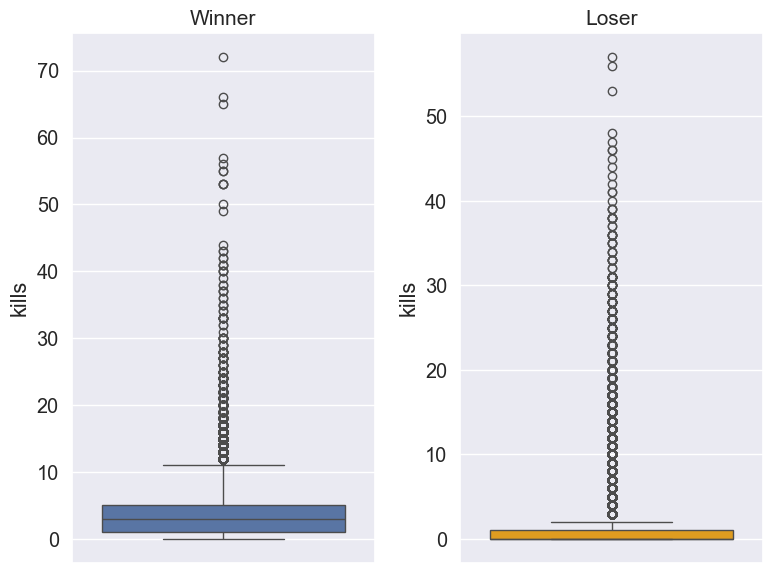

승리유저 평균 kills: 3.63
패배유저 평균 kills: 0.84


In [14]:
box_plot(winner, loser, 'kills')

#### 헤드샷 비율 비교

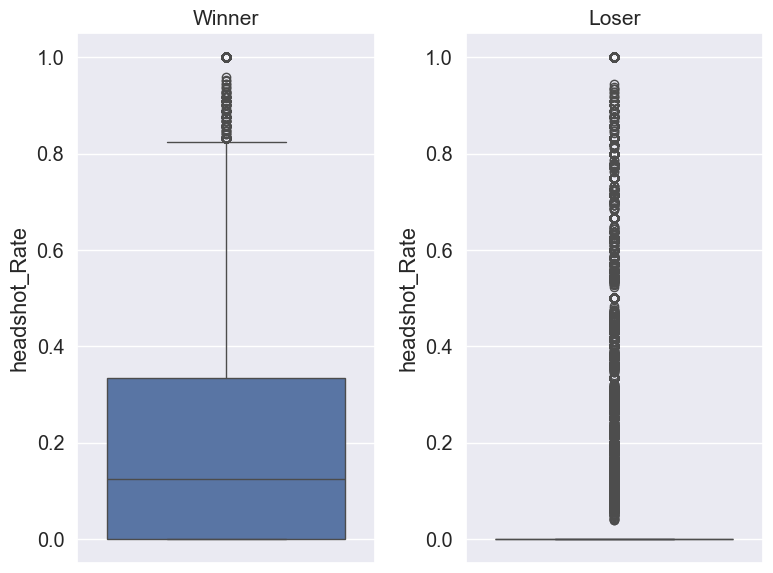

승리유저 평균 headshot_Rate: 0.22
패배유저 평균 headshot_Rate: 0.10


In [15]:
box_plot(winner, loser, 'headshot_Rate')

#### 어시스트 비교

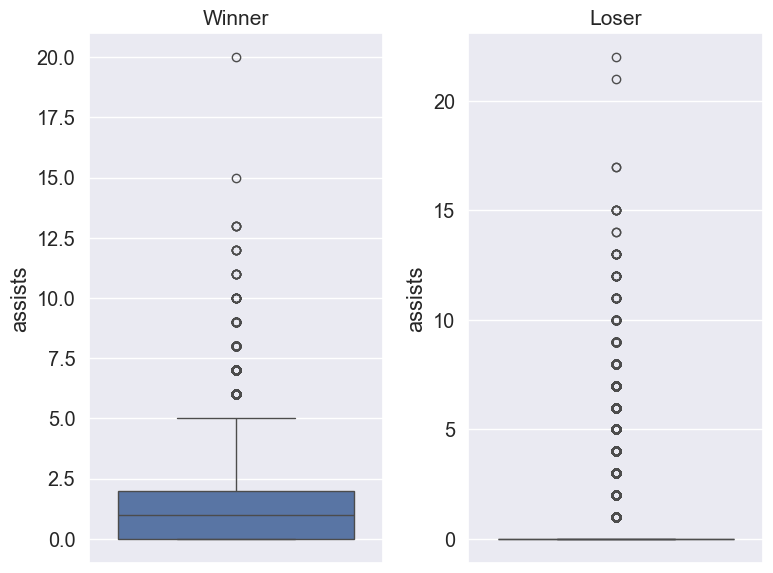

승리유저 평균 assists: 1.10
패배유저 평균 assists: 0.21


In [16]:
box_plot(winner, loser, 'assists')

#### 총 이동거리 비교

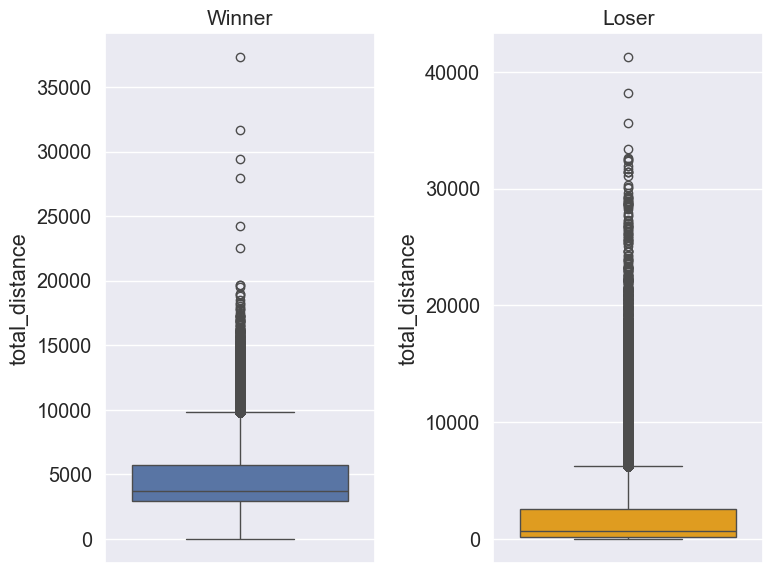

승리유저 평균 total_distance: 4455.76
패배유저 평균 total_distance: 1685.37


In [17]:
box_plot(winner, loser, 'total_distance')

#### 무기 획득 비교

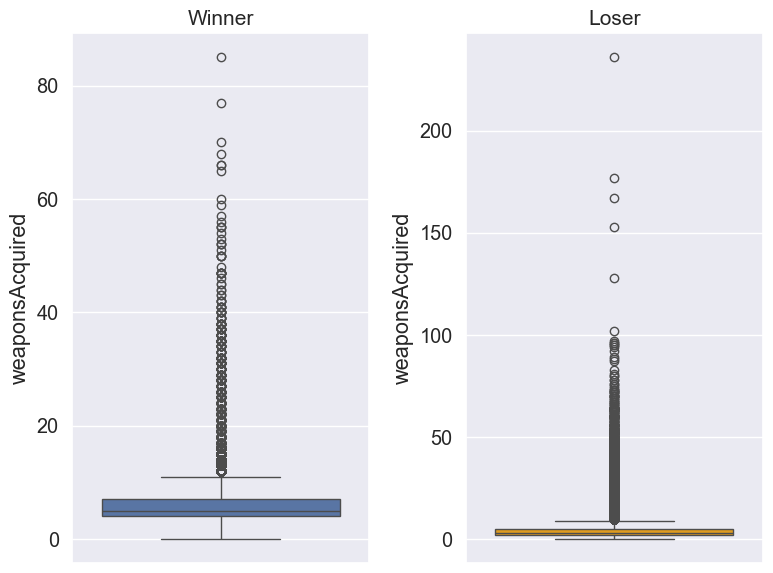

승리유저 평균 weaponsAcquired: 5.68
패배유저 평균 weaponsAcquired: 3.60


In [18]:
box_plot(winner, loser, 'weaponsAcquired')

### EDA 요약
- 승리 유저는 킬, 헤드샷비율, 어시스트, 총 이동거리, 무기 획득 수 등에서 패배유저보다 높은 수치를 나타낸다.
- 따라서 승리 유저 안에 핵 유저가 있을거라 판단

--------------------------------------

## 유저 분리
- 현재 이상치 라벨이 없기에 모델을 활용하여 핵/일반 유저 분리
- 위 EDA 결과 핵 사용자는 승리한 유저 패턴과 비슷하다고 추정
- 또한 핵을 사용하면 승리 가능성이 높아지기에 상관관계가 있다고 판단
- 최초에는 승리 예측값이 1인 유저들만을 대상으로 분석을 고려했으나, 이는 전체 데이터의 약 3%에 불과하여 심각한 데이터 손실을 초래
- 그래서 승리 예측값의 3분위수인 0.74 이상을 기준으로 범위 조정

In [19]:
pd.set_option('display.float_format', '{:,.2f}'.format)
df['winPlacePerc'].describe()

count   4,446,965.00
mean            0.47
std             0.31
min             0.00
25%             0.20
50%             0.46
75%             0.74
max             1.00
Name: winPlacePerc, dtype: float64

In [20]:
win = df[df['winPlacePerc'] >= 0.74]
print(f"전체 데이터 수: {len(df)}")
print(f"전처리 후 데이터 수: {len(win)}")
print('-' * 30)
print(f"제외한 데이터 비율: {(len(df) - len(win)) / len(df) * 100:.2f}%")
print(f"최종 데이터 비율: {len(win) / len(df) * 100:.2f}")

pd.set_option('display.float_format', '{:,.2f}'.format)

전체 데이터 수: 4446965
전처리 후 데이터 수: 1128703
------------------------------
제외한 데이터 비율: 74.62%
최종 데이터 비율: 25.38


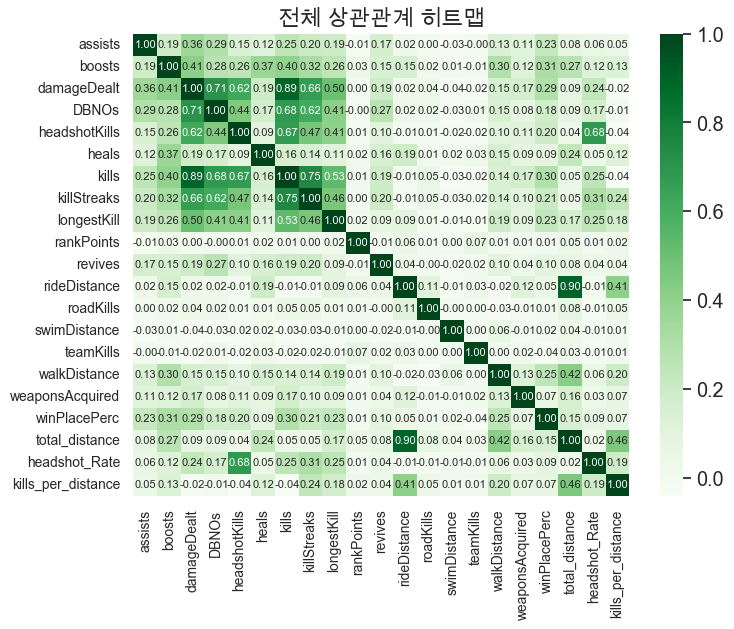

In [21]:
# 상관관계
heatmap(win, figsize=(8, 6), cmap='Greens', annot_kws={"size": 8})

### 비지도 학습
- Isolation Forest - ML
- AutoEncoder - DL
- 두 모델을 활용해 이상치로 판별된 데이터 간 교집합에 해당하는 유저를 핵 유저로 정의

In [22]:
def kdeplot_mean_std(win, hack_user, normal_user, col):
    """모델 score 간접적인 평가"""

    # KDE 시각화
    plt.figure(figsize=(8, 6))
    sns.kdeplot(normal_user[col], label='Normal_User', fill=True)
    sns.kdeplot(hack_user[col], label='Hack_User', fill=True, color='red')
    plt.title('Normal_User VS Hack_User')
    plt.legend()
    plt.show()

    hack_mean = np.mean(hack_user[col])  # 핵 유저의 평균
    hack_std = np.std(hack_user[col])  # 핵 유저의 표준편차
    normal_mean = np.mean(normal_user[col])  # 정상 유저의 평균
    normal_std = np.std(normal_user[col])  # 정상 유저의 표준편차

    print(f"Normal_User {col} 평균: {normal_mean:.4f} 표준편차: ({normal_std:.4f})")
    print(f"Hack_User {col} 평균: {hack_mean:.4f} 표준편차: ({hack_std:.4f})")
    print('-' * 60)
    print(f"Normal_User Length: {len(normal_user)}")
    print(f"Hack_User Length: {len(hack_user)}")
    print(f"Normal_User Rate: {len(normal_user) / len(win) * 100:.2f}%")
    print(f"Hack_User Rate: {len(hack_user) / len(win) * 100:.2f}%")

### IsolationForest

**이상치 비율(Contamination) 설정 근거**

- Krafton 공식 발표에 따르면 **2024년 상반기에만 148만 계정**이 불법 소프트웨어 사용으로 영구 밴되었으며, 지속적인 제재를 통해 핵 유저 비율은 **감소 추세**에 있음 ([PUBG Anti-Cheat 2024 1H Review](https://pubg.com/en/news/7584))
- 본 데이터는 **winPlacePerc ≥ 0.74의 상위권 플레이어**만을 대상으로 하며, 상위권일수록 핵 유저 밀도가 높은 경향이 있음
- 위를 고려하여 contamination을 **0.7%로 보수적으로 설정**, Isolation Forest와 AutoEncoder **두 모델의 AND 앙상블**을 통해 최종 이상치를 정의함으로써 **오탐(False Positive)을 최소화**

In [23]:
scaler = RobustScaler()
feature = scaler.fit_transform(win.drop(columns={'Id', 'groupId', 'matchType', 'rideDistance'})).copy() # rideDistance: 상관관계 9.0

# Isolation Forest 모델
iso_forest = IsolationForest(n_estimators=300, contamination=0.007, max_samples=0.3, random_state=42, n_jobs=-1)
iso_forest.fit(feature)

# 예측 및 이상치 점수 계산
win['iso_label'] = iso_forest.predict(feature)  # -1: 이상치, 1: 정상치
win['iso_score'] = iso_forest.decision_function(feature)  # 이상치 점수

iso_hack_user = win[win['iso_label'] == -1]
iso_normal_user = win[win['iso_label'] == 1]

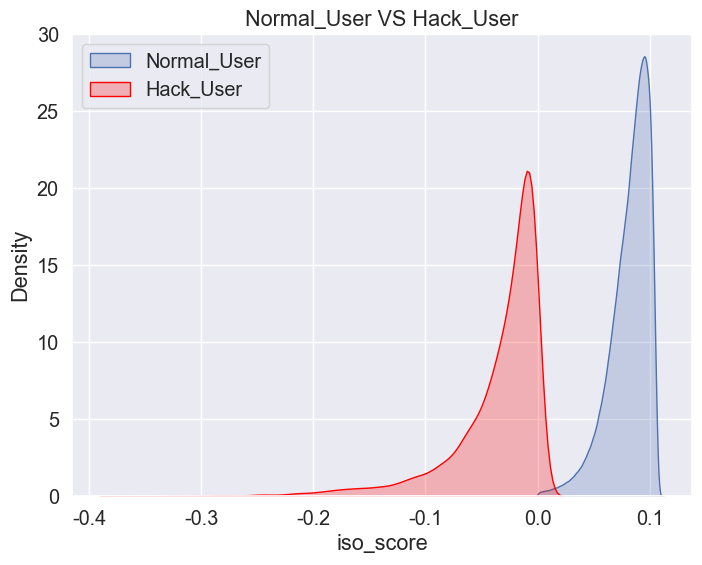

Normal_User iso_score 평균: 0.0814 표준편차: (0.0179)
Hack_User iso_score 평균: -0.0362 표준편차: (0.0428)
------------------------------------------------------------
Normal_User Length: 1120802
Hack_User Length: 7901
Normal_User Rate: 99.30%
Hack_User Rate: 0.70%


In [24]:
kdeplot_mean_std(win, iso_hack_user, iso_normal_user, 'iso_score')

### AutoEncoder


In [25]:
input_shape = win.select_dtypes(include=['number']).drop(columns={'iso_label', 'iso_score', 'rideDistance'})
print(f"Input shape: {len((input_shape.columns))}")
print(f"Data Length: {len(win)}")

Input shape: 20
Data Length: 1128703


In [26]:
import torch.nn as nn
import torch.optim as optim
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.mps.manual_seed(SEED)

# device = torch.device("cpu") # MPS 사용 시 오류 발생
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder: 압축
        self.encoder = nn.Sequential(
            nn.Linear(20, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )

        # Decoder: 복원
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 20),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Using device: mps


In [27]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)

# RMSE
def get_rmse_loss(y_pred, y_true):
    mse = criterion(y_pred, y_true)
    return torch.sqrt(mse)

In [28]:
from torch.utils.data import DataLoader, TensorDataset

# 데이터 전처리 및 로더 설정
data = win.select_dtypes(include=['number']).drop(columns={'iso_label', 'iso_score', 'rideDistance'})
scaler = RobustScaler()
feature = scaler.fit_transform(data)
feature = np.nan_to_num(feature, nan=0.0, posinf=0.0, neginf=0.0)

# train_feat, val_feat = train_test_split(feature, test_size=0.1, random_state=42)
# train_tensor = torch.tensor(train_feat, dtype=torch.float32)
# val_tensor = torch.tensor(val_feat, dtype=torch.float32)
feature_tensor = torch.tensor(feature, dtype=torch.float32)
dataset = TensorDataset(feature_tensor, feature_tensor)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

# 학습 설정
num_epochs =100
patience = 7
wait = 0
best_loss = float('inf')
best_weights = None

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = get_rmse_loss(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    # Val loss 계산
    # model.eval()
    # with torch.no_grad():
    #     val_out = model(val_tensor.to(device))
    #     val_loss = get_rmse_loss(val_out, val_tensor.to(device)).item()
    # model.train()

    # print(f"Epoch {epoch+1}/{num_epochs} - loss: {avg_loss:.4f} | val_loss: {val_loss:.4f}")
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)

    # Early Stopping (val_loss 기준)
    # if val_loss < best_loss:
    #     best_loss = val_loss
    #     wait = 0
    #     best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    
    # train loss
    if avg_loss < best_loss:
        best_loss = avg_loss
        wait = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()} 
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            if best_weights is not None:
                model.load_state_dict(best_weights)
            break

Epoch 1/100 - loss: 1.0754
Epoch 2/100 - loss: 0.4644
Epoch 3/100 - loss: 0.4061
Epoch 4/100 - loss: 0.3781
Epoch 5/100 - loss: 0.3619
Epoch 6/100 - loss: 0.3587
Epoch 7/100 - loss: 0.3493
Epoch 8/100 - loss: 0.3426
Epoch 9/100 - loss: 0.3379
Epoch 10/100 - loss: 0.3408
Epoch 11/100 - loss: 0.3170
Epoch 12/100 - loss: 0.3028
Epoch 13/100 - loss: 0.2959
Epoch 14/100 - loss: 0.2915
Epoch 15/100 - loss: 0.2881
Epoch 16/100 - loss: 0.2845
Epoch 17/100 - loss: 0.2855
Epoch 18/100 - loss: 0.2751
Epoch 19/100 - loss: 0.2777
Epoch 20/100 - loss: 0.2791
Epoch 21/100 - loss: 0.2761
Epoch 22/100 - loss: 0.2681
Epoch 23/100 - loss: 0.2576
Epoch 24/100 - loss: 0.2489
Epoch 25/100 - loss: 0.2444
Epoch 26/100 - loss: 0.2436
Epoch 27/100 - loss: 0.2422
Epoch 28/100 - loss: 0.2390
Epoch 29/100 - loss: 0.2371
Epoch 30/100 - loss: 0.2329
Epoch 31/100 - loss: 0.2365
Epoch 32/100 - loss: 0.2319
Epoch 33/100 - loss: 0.2349
Epoch 34/100 - loss: 0.2301
Epoch 35/100 - loss: 0.2286
Epoch 36/100 - loss: 0.2343
E

In [29]:
model.eval()                                                                                                     
with torch.no_grad():                                                                                            
    feature_tensor = torch.tensor(feature, dtype=torch.float32).to(device)                                       
    reconstructions = model(feature_tensor).cpu().numpy()                                                        
                                                                                                                
reconstruction_error = np.sqrt(np.mean(np.square(feature - reconstructions), axis=1))                            
                                                                                                                
win['auto_score'] = reconstruction_error
win['auto_score'].describe()

count   1,128,703.00
mean            0.17
std             0.11
min             0.02
25%             0.08
50%             0.15
75%             0.23
max             5.03
Name: auto_score, dtype: float64

임계값 (Threshold): 0.5219
이상치 비율: 0.70%


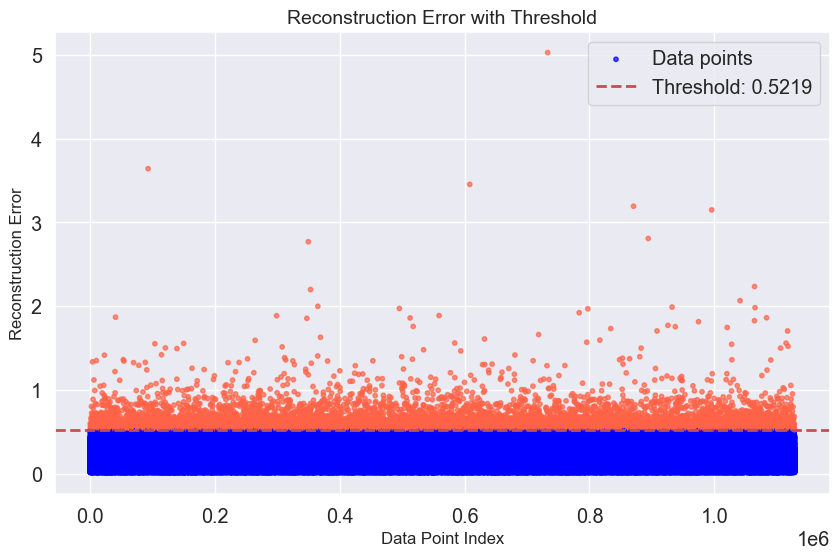

In [30]:
# 임계값 설정 (Isolation Forest contamination=0.7%에 맞춤)                                                       
threshold = np.percentile(win['auto_score'], 99.3)
print(f"임계값 (Threshold): {threshold:.4f}")                                              
print(f"이상치 비율: {(win['auto_score'] > threshold).mean():.2%}")                                                                                                    
colors = ['tomato' if score > threshold else 'blue' for score in win['auto_score']]                            

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(win)), win['auto_score'], c=colors, alpha=0.7, s=10, label='Data points')
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title("Reconstruction Error with Threshold", fontsize=14)
plt.xlabel("Data Point Index", fontsize=12)
plt.ylabel("Reconstruction Error", fontsize=12)
plt.legend()
plt.show()

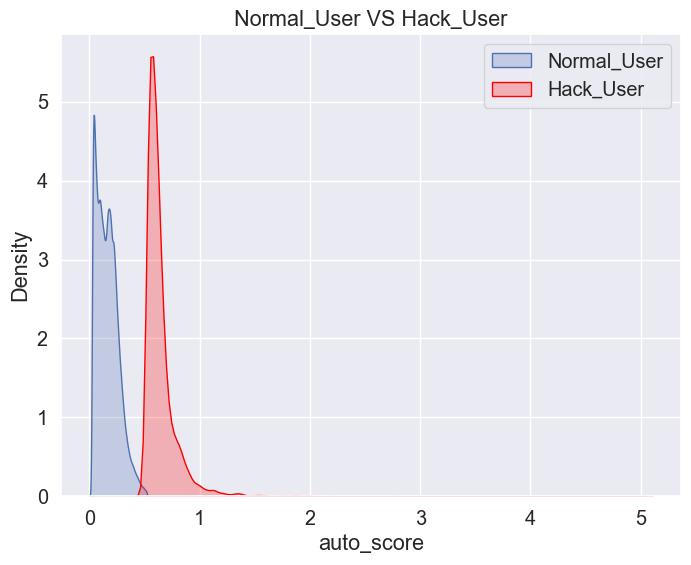

Normal_User auto_score 평균: 0.1621 표준편차: (0.0980)
Hack_User auto_score 평균: 0.6433 표준편차: (0.1712)
------------------------------------------------------------
Normal_User Length: 1120802
Hack_User Length: 7901
Normal_User Rate: 99.30%
Hack_User Rate: 0.70%


In [31]:
# 핵 유저와 노말 유저 분리
win['auto_label'] = np.where(win['auto_score'] > threshold, -1, 1)

# 분리된 데이터 확인
auto_hack_user = win[win['auto_label'] == -1]  # 핵 유저
auto_normal_user = win[win['auto_label'] == 1]  # 노말 유저

kdeplot_mean_std(win, auto_hack_user, auto_normal_user, 'auto_score') # 시각화 및 평균, 표준편차 함수

#### 두 모델의 교집합

In [32]:
final_df = win.copy()
final_df['True_label'] = 0

final_df.loc[(final_df['iso_label'] == -1) & (final_df['auto_label'] == -1), 'True_label'] = 1  # True_label : 이진 분류를 위해 0과 1로 설정 / 1 = 핵 유저
final_df = final_df.drop(columns={'iso_score', 'iso_label', 'auto_score', 'auto_label'})

hack_user = final_df[final_df['True_label'] == 1]
normal_user = final_df[final_df['True_label'] == 0]
hack_ratio = len(hack_user) / len(final_df) * 100
normal_ratio = len(normal_user) / len(final_df) * 100

print(f"일반 사용자 수: {len(normal_user)}명")
print(f"핵 사용자 수: {len(hack_user)}명")
print('-' * 50)
print(f"일반 사용자 비율: {normal_ratio:.2f}%")
print(f"핵 사용자 비율: {hack_ratio:.2f}%")

일반 사용자 수: 1126532명
핵 사용자 수: 2171명
--------------------------------------------------
일반 사용자 비율: 99.81%
핵 사용자 비율: 0.19%


### 결과
- Isolation Forest 모델과 Autoencoder 모델을 활용하여 kdeplot 시각화를 통해 두 그룹이 어느 정도 명확하게 분리됨을 확인
- 그러나 완벽히 분리되었다고 보기에는 어려운 점이 있으며, 이는 실무에서도 이상 탐지에서 정상 데이터와 이상치를 완벽히 분리하기 어려운 경우가 많다는 점을 시사한다.
- 이는 실제로 이상 탐지의 목표가 완벽한 분리보다는 효과적으로 이상치를 탐지하는 데 있다는 점에서 비롯되며, 데이터의 복잡성과 이상치 정의의 모호성 등으로 인해 정상 데이터와 이상치 간 경계가 불분명한 경우가 많다.

------------------------------------------------------------------------------

## 라벨 검증
- 라벨의 신빙성을 위해 핵/일반 유저의 통계적 검정

### 가설 설정
- 가설1 : 핵 사용자들은 일반 사용자랑 다르게 헤드샷 비율이 높을 것이다.(정확한 에임 핵을 사용)
- 가설2 : 핵 사용자들은 일반 사용자 보다 무기 획득 수가 많다.(스피드 핵, 월핵 등 사용)
- 가설3 : 핵 사용자들은 일반 사용자 보다 힐 아이템 사용이 많을 것이다.(스피드 핵, 월핵 등 사용)

### 가설 검정
- VIF
- Propensity Score Matching (PSM)
- mannwhitneyu U-검정

#### VIF
- PSM 전 회귀분석을 위해 다중공선성 확인
- VIF(분산팽창요인, Variance Inflation Factor) : 변수간의 다중공선성을 진단하는 수치이며, 범위는 1부터 무한대이다.
- VIF 값이 10 이상이면 다중공선성이 있다고 판단한다.

In [33]:
number = final_df.select_dtypes(include=['number']).drop(columns={'True_label', 'rideDistance'})
vif_with_constant = add_constant(number)

vif = pd.DataFrame()
vif['features'] = vif_with_constant.columns
vif['VIF Factor'] =  [round(variance_inflation_factor(vif_with_constant.values, i), 4) for i in range(vif_with_constant.shape[1])]

vif = vif.sort_values('VIF Factor', ascending=False).reset_index(drop=True)
vif = vif[vif['features'] != 'const']
vif

,features,VIF Factor
1,kills,9.11
2,damageDealt,6.14
3,headshotKills,4.23
4,killStreaks,3.32
5,headshot_Rate,2.63
6,DBNOs,2.36
7,kills_per_distance,1.77
8,total_distance,1.69
9,longestKill,1.54
10,boosts,1.51


### Propensity Score Matching (PSM)

- 두 그룹의 샘플 크기에서 큰 불균형이 존재하여 직접적인 비교가 어렵고 결과의 신뢰성에 문제 발생, 결과 분석에서 발생하는 편향으로 인해 잘못된 결론을 도출할 수 있다.
- PSM을 사용함으로, 그룹 간의 비슷한 조건에서의 차이를 평가할 수 있고, 결과적으로 잠재적인 혼란 변수를 줄이고 분석의 정확도를 높인다.
- LogisticRegression을 사용해서 Propensity Score 계산
- 가설 설정한 변수들은 제외시킨 후 진행

In [34]:
scaler = RobustScaler()
df_psm = final_df.copy()

scale_features = df_psm.drop(columns={'Id', 'groupId', 'matchType', 'True_label'})
scaled_features = scaler.fit_transform(scale_features)
scaled_df = pd.DataFrame(scaled_features, columns=scale_features.columns)
scaled_df[['Id', 'True_label']] = df_psm[['Id', 'True_label']]
scaled_df.replace([np.inf, -np.inf], np.nan, inplace=True)
scaled_df.dropna(inplace=True)

# PSM 진행
psm = PsmPy(data=scaled_df, treatment='True_label', indx='Id', exclude=['headshot_Rate', 'weaponsAcquired', 'heals']) # exclude : 제외 컬럼
psm.logistic_ps(balance=True)  # 로지스틱 회귀로 Propensity Score 계산

# Propensity Score 및 로그 계산
scaled_df['propensity_score'] = psm.predicted_data['propensity_score']
scaled_df['propensity_logit'] = scaled_df['propensity_score'].apply(lambda p: np.log(p / (1 - p)) if 0 < p < 1 else np.nan)

# 무한대 및 NaN 값 처리
scaled_df['propensity_logit'].replace([np.inf, -np.inf], np.nan, inplace=True)
scaled_df.dropna(subset=['propensity_logit'], inplace=True)

# K-최근접 이웃 매칭
psm.kdtree_matched(matcher='propensity_logit', replacement=False)

matched_df = psm.df_matched
matched_df

,Id,assists,boosts,damageDealt,DBNOs,headshotKills,kills,killStreaks,longestKill,rankPoints,...,swimDistance,teamKills,walkDistance,winPlacePerc,total_distance,kills_per_distance,propensity_score,propensity_logit,True_label,matched_ID
0,7711e1d39407da,2.00,-0.67,-0.13,-0.50,0.00,0.00,0.00,0.66,-0.97,...,0.00,0.00,-0.84,0.55,-0.50,0.49,0.44,-0.26,1,3dbe416b6aa4b9
1,0fa60dc56fdb16,1.00,0.00,0.06,-0.50,0.00,-0.33,-1.00,-0.32,-0.97,...,0.00,0.00,0.87,0.53,0.15,-0.42,0.48,-0.07,1,1fd49f7e3b0bb5
2,ff55cd7dacdf83,0.00,-1.00,-0.69,-0.50,0.00,-0.33,-1.00,-0.32,0.23,...,21.63,0.00,-0.53,0.21,-0.50,-0.42,0.50,-0.01,1,1dda2ffb6ee653
3,d5d2401c2fbd50,0.00,0.33,-0.04,0.00,0.00,0.33,1.00,-0.23,0.07,...,27.37,0.00,0.07,-0.79,-0.22,0.20,0.52,0.10,1,57a1758283b19e
4,550398a8f33db7,0.00,-0.67,-0.32,-0.50,0.00,0.00,0.00,0.40,0.05,...,0.00,0.00,-0.51,0.21,-0.50,0.49,0.49,-0.03,1,5b563245e02da7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,87d60cc9cba2b7,1.00,0.67,0.01,-0.50,0.00,0.33,0.00,0.47,-0.97,...,0.00,0.00,0.73,0.05,1.91,1.44,0.55,0.20,0,NaN
1176,e86952102edce7,0.00,0.33,-0.32,0.00,0.00,0.00,0.00,-0.31,-0.03,...,0.00,0.00,0.07,-0.30,1.10,2.35,0.56,0.24,0,NaN
1177,ecd21783b67ff9,0.00,-0.67,0.01,-0.50,0.00,0.00,0.00,-0.19,0.04,...,0.00,0.00,-0.50,0.42,-0.43,0.57,0.45,-0.22,0,NaN
1178,60ee177d19c57f,0.00,0.00,-0.36,0.00,0.00,0.00,0.00,0.37,0.02,...,0.00,0.00,0.49,0.33,2.36,3.82,0.46,-0.17,0,NaN


### U 검정
- 데이터 확인 결과 대부분이 비정규성 분포를 나타남으로 u-검정으로 사용
- u 검정 시 p-value 값이 0.05 이하여야 그룹 간 통계적 의미가 유의미하다고 판단
- 귀무 가설: 두 그룹 간에 차이가 없다.
- 대립 가설: 두 그룹 간에 차이가 있다.

In [35]:
matched_df = matched_df.merge(df_psm[['Id', 'headshot_Rate', 'heals', 'weaponsAcquired']], on='Id', how='left') # 매핑
hack_user_psm = matched_df[matched_df['True_label'] == 1] # 핵 유저
normal_user_psm = matched_df[matched_df['True_label'] == 0] # 일반 유저

print(f'PSM 후 핵 유저: {len(hack_user_psm)}')
print(f'PSM 후 일반 유저: {len(normal_user_psm)}')

PSM 후 핵 유저: 590
PSM 후 일반 유저: 590


In [36]:
def U_test_boxplot(normal_user, hack_user, col):

  fig, axes = plt.subplots(1, 2, figsize=(8, 6))
  sns.boxplot(normal_user[col], ax=axes[0])
  axes[0].set_title('Normal User', fontsize=15)

  sns.boxplot(hack_user[col], ax=axes[1], color='red')
  axes[1].set_title('Hack User', fontsize=15)

  plt.tight_layout()
  plt.show()

  # u 검정 확인
  u_stat, p_value = mannwhitneyu(hack_user[col], normal_user[col], alternative='greater') # greater = 첫 번쨰 그룹의 값이 두 번쨰 그룹의 값보다 더 많다.

  threshold = 0.05
  if p_value < threshold:
      print('귀무가설을 기각하고, 대립가설을 채택! 유의미한 차이가 존재')
  else:
      print('귀무가설을 채택. 두 그룹 간에 유의미한 차이가 존재하지 않다.')
  print(f"U-검정 통계값: {u_stat}, p-value: {p_value:.4f}")

#### 검정 1.
- 가설1 : 핵 사용자들은 일반 사용자랑 다르게 헤드샷 비율이 높을 것이다.(정확한 에임 핵을 사용)

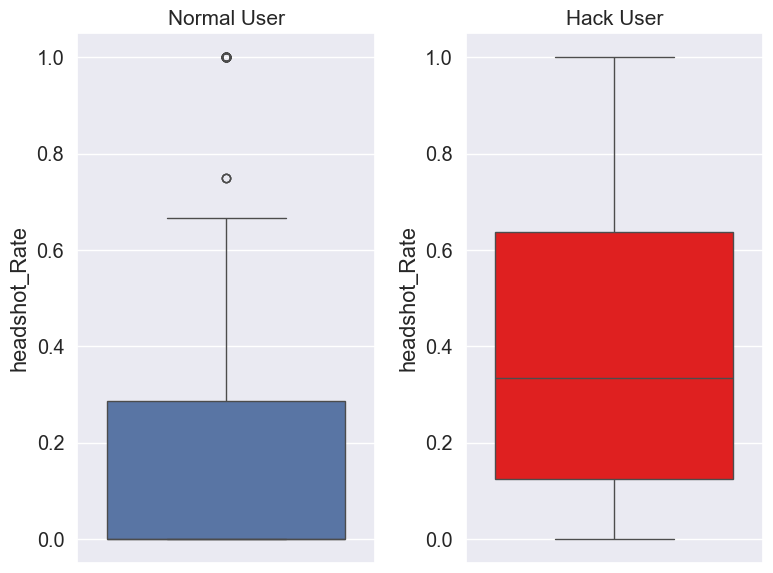

귀무가설을 기각하고, 대립가설을 채택! 유의미한 차이가 존재
U-검정 통계값: 253062.0, p-value: 0.0000


In [37]:
U_test_boxplot(normal_user_psm, hack_user_psm, 'headshot_Rate')

#### 검정 2.
- 가설2 : 핵 사용자들은 일반 사용자 보다 무기 획득 수가 많다.(스피드 핵, 월핵 등 사용)

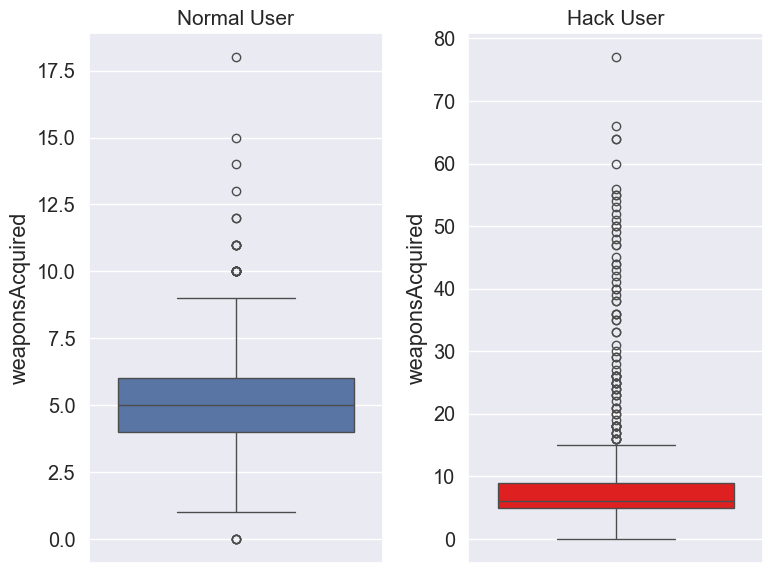

귀무가설을 기각하고, 대립가설을 채택! 유의미한 차이가 존재
U-검정 통계값: 217966.5, p-value: 0.0000


In [38]:
U_test_boxplot(normal_user_psm, hack_user_psm, 'weaponsAcquired')

#### 검정 3.
- 가설3 : 핵 사용자들은 일반 사용자 보다 힐 아이템 사용이 많을 것이다.(스피드 핵, 월핵 등 사용)

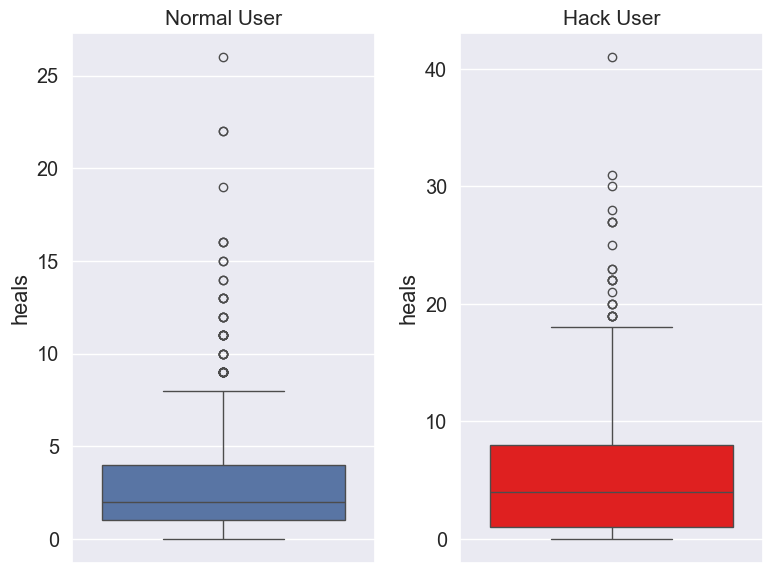

귀무가설을 기각하고, 대립가설을 채택! 유의미한 차이가 존재
U-검정 통계값: 219238.5, p-value: 0.0000


In [39]:
U_test_boxplot(normal_user_psm, hack_user_psm, 'heals')

### 다른 변수 비교
- 이 비교에선 원본 데이터로 U검정 수행(성향 매칭 분석 외 기존 데이터프레임 비교)
- 연속 킬 수
- 총 이동거리

In [40]:
def U_test_mean_std(normal, hack, col):

    fig, axes = plt.subplots(1, 2, figsize=(8, 6))

    sns.boxplot(ax=axes[0], y=normal[col])
    axes[0].set_title('normal', fontsize=15)
    sns.boxplot(ax=axes[1], y=hack[col], color='orange')
    axes[1].set_title('hack', fontsize=15)
    plt.tight_layout()
    plt.show()

    # u 검정 확인
    u_stat, p_value = mannwhitneyu(hack_user[col], normal_user[col])

    threshold = 0.05
    if p_value < threshold:
        print('두 그룹 간에 유의미한 차이가 존재')
    else:
        print('두 그룹 간에 유의미한 차이가 존재하지 않음')
    print(f"U-검정 통계값: {u_stat}, p-value: {p_value:.4f}")
    print('-' * 60)
    print(f"일반 유저 평균 {col}: {normal[col].mean():.2f}")
    print(f"핵 유저 평균 {col}: {hack[col].mean():.2f}")

#### 연속 킬 수

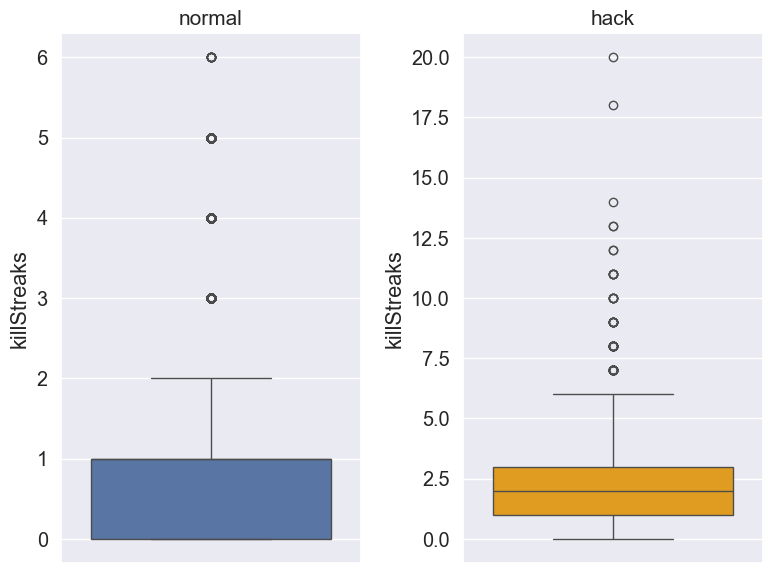

두 그룹 간에 유의미한 차이가 존재
U-검정 통계값: 2022914881.5, p-value: 0.0000
------------------------------------------------------------
일반 유저 평균 killStreaks: 0.92
핵 유저 평균 killStreaks: 2.52


In [41]:
U_test_mean_std(normal_user, hack_user, 'killStreaks')

#### 총 이동거리

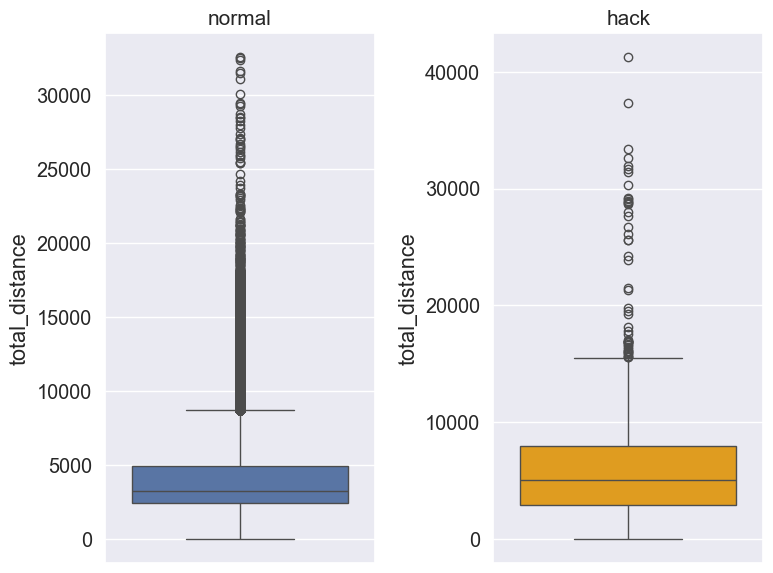

두 그룹 간에 유의미한 차이가 존재
U-검정 통계값: 1563013874.5, p-value: 0.0000
------------------------------------------------------------
일반 유저 평균 total_distance: 3864.49
핵 유저 평균 total_distance: 5723.30


In [42]:
U_test_mean_std(normal_user, hack_user, 'total_distance')

### 검정 결과
- 모든 가설이 유의미한 결과로 대립가설을 채택
- 라벨의 신빙성을 확인
- 이 라벨을 가지고 모델 학습 및 평가

----------------------------------------------------

## 지도 학습

In [65]:
label = final_df['True_label']                                                                             
raw_feature = final_df.select_dtypes(include=['number']).drop(columns={'True_label', 'winPlacePerc'}) # winPlacePerc          
                                                                                                                
X_train, X_test, y_train, y_test = train_test_split(                                                             
    raw_feature, label, test_size=0.2, random_state=42, stratify=label)                                          
                                                                                                                
X_train, X_val, y_train, y_val = train_test_split(                                                               
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)                                         

print(f"Train: {X_train.shape} ({y_train.mean()*100:.3f}% hack)")
print(f"Val: {X_val.shape} ({y_val.mean()*100:.3f}% hack)")
print(f"Test: {X_test.shape} ({y_test.mean()*100:.3f}% hack)")

Train: (677221, 20) (0.192% hack)
Val: (225741, 20) (0.192% hack)
Test: (225741, 20) (0.192% hack)


### 상관관계

In [ ]:
def plot_corr(df, figsize=(8, 14), threshold=0, cmap='coolwarm',                                                       
                        method='pearson', annot_kws=None, return_data=False):                                                   
    if annot_kws is None:                                                                                                         
        annot_kws = {"size": 9}                                                                                                 

    exclude = ['True_label', 'winPlacePerc']
    num_df  = df.select_dtypes(include=['number'])

    target  = num_df['True_label']
    features = num_df.drop(columns=[c for c in exclude if c in num_df.columns])

    corr_series  = features.corrwith(target, method=method)
    corr_filtered = corr_series[abs(corr_series) >= threshold].sort_values(ascending=False)

    plt.figure(figsize=figsize)
    sns.heatmap(corr_filtered.to_frame(name='Correlation'),
                annot=True, fmt='.2f', cmap=cmap,
                annot_kws=annot_kws, cbar=True, center=0)
    plt.title(f'{method.capitalize()} Correlation with True_label', fontsize=14)
    plt.tight_layout()
    plt.show()

    if return_data:
        corr_df = corr_filtered.reset_index()
        corr_df.columns = ['Variable', 'Correlation']
        return corr_df

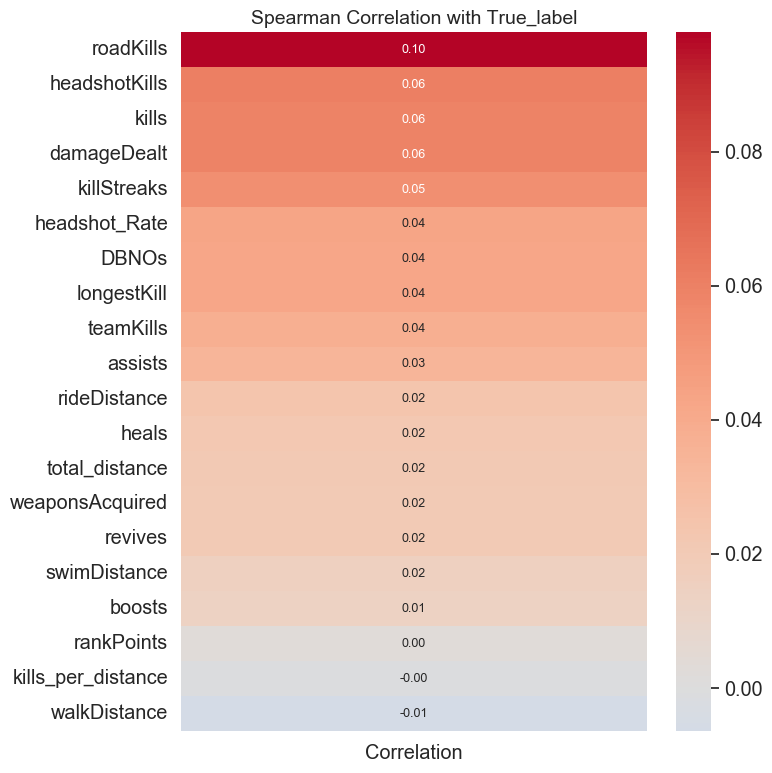

In [63]:
plot_corr(raw_feature, method='spearman')

In [130]:
from sklearn.metrics import precision_recall_curve, auc

def Models_evaluation(y_true, y_pred, y_pred_proba=None):                                                                         
    metrics = {}                                                                                                                                                                                                                              
    metrics['precision'] = precision_score(y_true, y_pred)                                                                        
    metrics['recall']    = recall_score(y_true, y_pred)                                                                           
    metrics['f1_score']  = f1_score(y_true, y_pred)                                                                               
                                                                                                                                
    if y_pred_proba is not None:
        precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_proba)
        metrics['pr_auc'] = auc(recall_curve, precision_curve)
    else:
        metrics['pr_auc'] = None

    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric.capitalize()}: {value:.4f}")
        else:
            print(f"{metric.capitalize()}: Not Available")

    return metrics

In [66]:
import math

def build_model(model_type, method, y_train):                                                                    
    """                                                                                                          
    model_type : 'xgb' | 'lgb' | 'cat'                                                                           
    method     : 'base' | 'class_weight' | 'smote'                                                               
    """
    ratio = (y_train == 0).sum() / (y_train == 1).sum()
    spw   = math.sqrt(ratio)  # scale_pos_weight (sqrt 기준)

    if model_type == 'xgb':
        params = dict(objective='binary:logistic', eval_metric='aucpr',
                    max_depth=8, colsample_bytree=0.8,
                    learning_rate=0.05, n_estimators=300,
                    random_state=42, use_label_encoder=False, tree_method='hist')
        if method == 'class_weight':
            params['scale_pos_weight'] = spw
        return xgb.XGBClassifier(**params)

    elif model_type == 'lgb':
        import lightgbm as lgb
        params = dict(objective='binary', metric='average_precision',
                    max_depth=8, colsample_bytree=0.8,
                    learning_rate=0.05, n_estimators=300,
                    random_state=42, verbose=-1)
        if method == 'class_weight':
            params['class_weight'] = {0: 1, 1: spw}
        return lgb.LGBMClassifier(**params)

    elif model_type == 'cat':
        from catboost import CatBoostClassifier
        params = dict(iterations=300, depth=8,
                    learning_rate=0.05, random_seed=42,
                    eval_metric='AUC', verbose=0)
        if method == 'class_weight':
            params['class_weights'] = [1, spw]
        return CatBoostClassifier(**params)

    else:
        raise ValueError(f"지원하지 않는 model_type: {model_type}")

In [79]:
import io, contextlib                                                                                          
                                                                                                                
def train_evaluate(model_type, method, X_train, y_train, X_val, y_val, smote_ratio=0.02):
    scaler = RobustScaler()                                                                                      
    X_tr = scaler.fit_transform(X_train)                                                                       
    X_vl = scaler.transform(X_val)                                                                             
    y_tr = y_train.copy()                                                                                      
                                                                                                                
    if method == 'smote':
        smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    model = build_model(model_type, method, y_tr)
    model.fit(X_tr, y_tr)

    pred = model.predict(X_vl)
    pred_proba = model.predict_proba(X_vl)[:, 1]

    with contextlib.redirect_stdout(io.StringIO()):
        metrics = Models_evaluation(y_val, pred, pred_proba)

    ratio_info = f" | ratio={smote_ratio:.4f}" if method == 'smote' else ""                                                         
    print(f"{model_type.upper()} | {method}{ratio_info} : F1={metrics['f1_score']:.4f}")
    return metrics, pred, pred_proba, model

XGB | smote | ratio=0.0050 : F1=0.5501
XGB | smote | ratio=0.0100 : F1=0.6086
XGB | smote | ratio=0.0200 : F1=0.6097
XGB | smote | ratio=0.0500 : F1=0.6158
XGB | smote | ratio=0.1000 : F1=0.6261
----------------------------------------
LGB | smote | ratio=0.0050 : F1=0.5892
LGB | smote | ratio=0.0100 : F1=0.6077
LGB | smote | ratio=0.0200 : F1=0.6163
LGB | smote | ratio=0.0500 : F1=0.5968
LGB | smote | ratio=0.1000 : F1=0.6014
----------------------------------------
CAT | smote | ratio=0.0050 : F1=0.5753
CAT | smote | ratio=0.0100 : F1=0.5826
CAT | smote | ratio=0.0200 : F1=0.6015
CAT | smote | ratio=0.0500 : F1=0.5960
CAT | smote | ratio=0.1000 : F1=0.5959
----------------------------------------


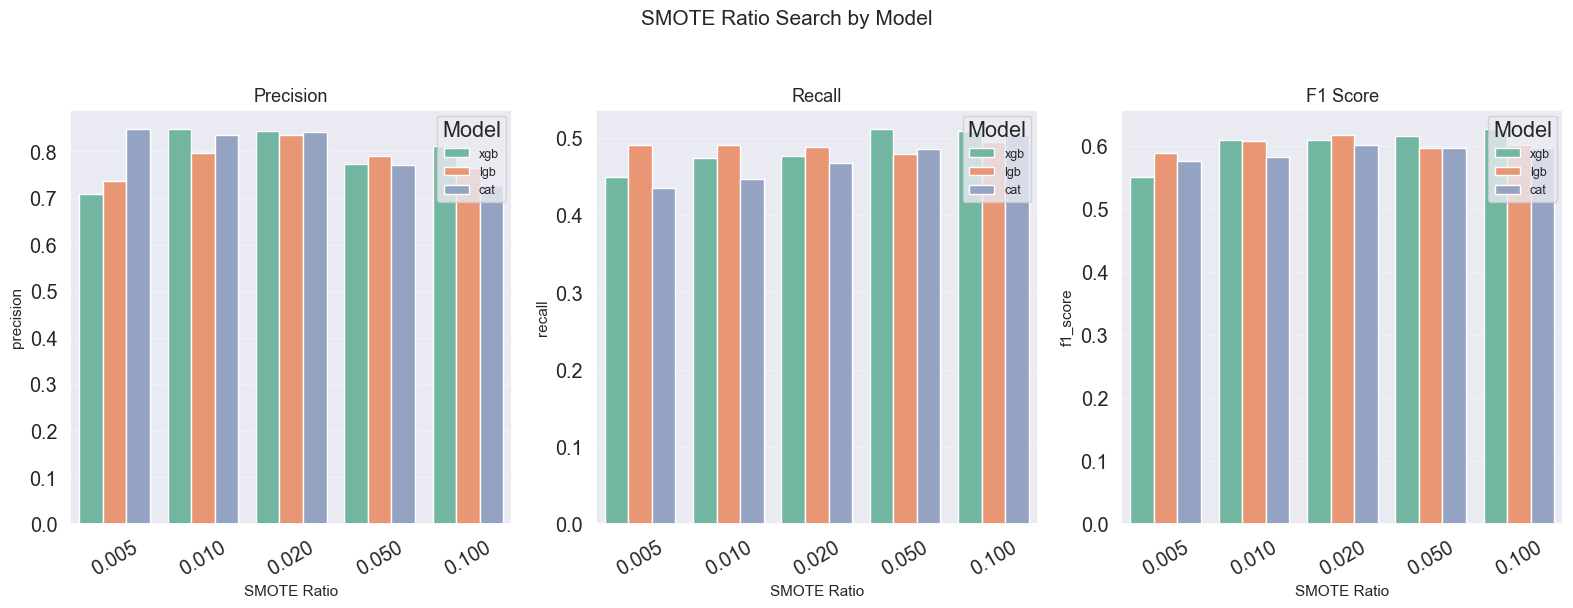

precision  recall  f1_score  pr_auc
Model SMOTE Ratio                                     
xgb   0.01              0.71    0.45      0.55    0.62
      0.01              0.85    0.47      0.61    0.71
      0.02              0.84    0.48      0.61    0.70
      0.05              0.77    0.51      0.62    0.68
      0.10              0.81    0.51      0.63    0.70
lgb   0.01              0.74    0.49      0.59    0.67
      0.01              0.80    0.49      0.61    0.70
      0.02              0.83    0.49      0.62    0.71
      0.05              0.79    0.48      0.60    0.71
      0.10              0.77    0.50      0.60    0.71
cat   0.01              0.85    0.44      0.58    0.71
      0.01              0.84    0.45      0.58    0.70
      0.02              0.84    0.47      0.60    0.70
      0.05              0.77    0.49      0.60    0.69
      0.10              0.73    0.50      0.60    0.68

In [131]:
MODEL_TYPES = ['xgb', 'lgb', 'cat']
SMOTE_RATIOS = [0.005, 0.01, 0.02, 0.05, 0.1]                                                                                                                   
smote_search = {}                                                                                                                 
                                                                                                                                    
for model_type in MODEL_TYPES:                                                                                                    
    for ratio in SMOTE_RATIOS:                                                                                                  
        key = f"{model_type}_{ratio}"
        metrics, _, _, _ = train_evaluate(
            model_type, 'smote', X_train, y_train, X_val, y_val, smote_ratio=ratio)
        smote_search[key] = metrics
    print("-" * 40)

smote_df = (pd.DataFrame(smote_search).T
            .astype(float)
            .round(4))
smote_df.index = pd.MultiIndex.from_tuples(
    [(k.rsplit('_', 1)[0], float(k.rsplit('_', 1)[1])) for k in smote_df.index],
    names=['Model', 'SMOTE Ratio'])

plot_df = smote_df.reset_index()                                                                                                  
metrics_to_plot = ['precision', 'recall', 'f1_score']                                                                                             
fig, axes = plt.subplots(1, 3, figsize=(16, 6))                                                                                   

for ax, metric in zip(axes, metrics_to_plot):                                                                                     
    sns.barplot(                                                                                                                
        data=plot_df,
        x='SMOTE Ratio', y=metric, hue='Model',
        palette='Set2', ax=ax
    )
    ax.set_title(metric.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('SMOTE Ratio', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.legend(title='Model', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([f'{r:.3f}' for r in SMOTE_RATIOS], rotation=30)

plt.suptitle('SMOTE Ratio Search by Model', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

smote_df

### Base

In [132]:
METHODS = ['base', 'class_weight', 'smote']

results = {}
predictions = {}
models_dict = {}

for model_type in MODEL_TYPES:
    for method in METHODS:
        key = f"{model_type}_{method}"
        metrics, pred, pred_proba, model = train_evaluate(
            model_type, method, X_train, y_train, X_val, y_val, smote_ratio=0.05) # AVG Smote
        results[key]     = metrics
        predictions[key] = (pred, pred_proba)
        models_dict[key] = model
    print('-' * 40)

results_df = (pd.DataFrame(results).T
                .astype(float)
                .round(4))
results_df.index = pd.MultiIndex.from_tuples(
    [k.split('_', 1) for k in results_df.index],
    names=['Model', 'Method'])
    
results_df.style.format('{:.4f}')
results_df

XGB | base : F1=0.6094
XGB | class_weight : F1=0.6017
XGB | smote | ratio=0.0500 : F1=0.6158
----------------------------------------
LGB | base : F1=0.5161
LGB | class_weight : F1=0.5928
LGB | smote | ratio=0.0500 : F1=0.5968
----------------------------------------
CAT | base : F1=0.5697
CAT | class_weight : F1=0.5597
CAT | smote | ratio=0.0500 : F1=0.5960
----------------------------------------


precision  recall  f1_score  pr_auc
Model Method                                           
xgb   base               0.88    0.47      0.61    0.73
      class_weight       0.64    0.57      0.60    0.67
      smote              0.77    0.51      0.62    0.68
lgb   base               0.59    0.46      0.52    0.49
      class_weight       0.49    0.76      0.59    0.72
      smote              0.79    0.48      0.60    0.71
cat   base               0.87    0.42      0.57    0.70
      class_weight       0.44    0.76      0.56    0.69
      smote              0.77    0.49      0.60    0.69

### Feature Engineering

In [83]:
raw_feature_V2 = raw_feature.copy()
kills_safe = raw_feature_V2['kills'].replace(0, np.nan)
dist_safe = raw_feature_V2['total_distance'].reimage.pngplace(0, np.nan)
weapons_safe = raw_feature_V2['weaponsAcquired'].replace(0, np.nan)

# 킬당 데미지, 킬당 평균 교전거리, 이동 없이 무기 수집, 킬 대비 기절 비율, 킬 대비 힐 사용 등 추가
raw_feature_V2['damage_per_kill']   = (raw_feature_V2['damageDealt'] / raw_feature_V2['kills'].replace(0, np.nan)).fillna(0)
raw_feature_V2['avg_kill_distance'] = (raw_feature_V2['longestKill']  / raw_feature_V2['kills'].replace(0, np.nan)).fillna(0)
raw_feature_V2['weapons_per_dist']  = (raw_feature_V2['weaponsAcquired'] / raw_feature_V2['total_distance'].replace(0, np.nan)).fillna(0)
raw_feature_V2['DBNO_per_kill']     = (raw_feature_V2['DBNOs']   / raw_feature_V2['kills'].replace(0, np.nan)).fillna(0)
raw_feature_V2['heals_per_kill']    = (raw_feature_V2['heals']   / raw_feature_V2['kills'].replace(0, np.nan)).fillna(0)

X_train_V2, X_test_V2, y_train_V2, y_test_V2 = train_test_split(
    raw_feature_V2, label, test_size=0.2, random_state=42, stratify=label)
X_train_V2, X_val_V2, y_train_V2, y_val_V2 = train_test_split(
    X_train_V2, y_train_V2, test_size=0.25, random_state=42, stratify=y_train_V2)

print(f"Train: {X_train_V2.shape} ({y_train_V2.mean()*100:.3f}% hack)")
print(f"Val: {X_val_V2.shape} ({y_val_V2.mean()*100:.3f}% hack)")
print(f"Test: {X_test_V2.shape} ({y_test_V2.mean()*100:.3f}% hack)")

Train: (677221, 25) (0.192% hack)
Val: (225741, 25) (0.192% hack)
Test: (225741, 25) (0.192% hack)


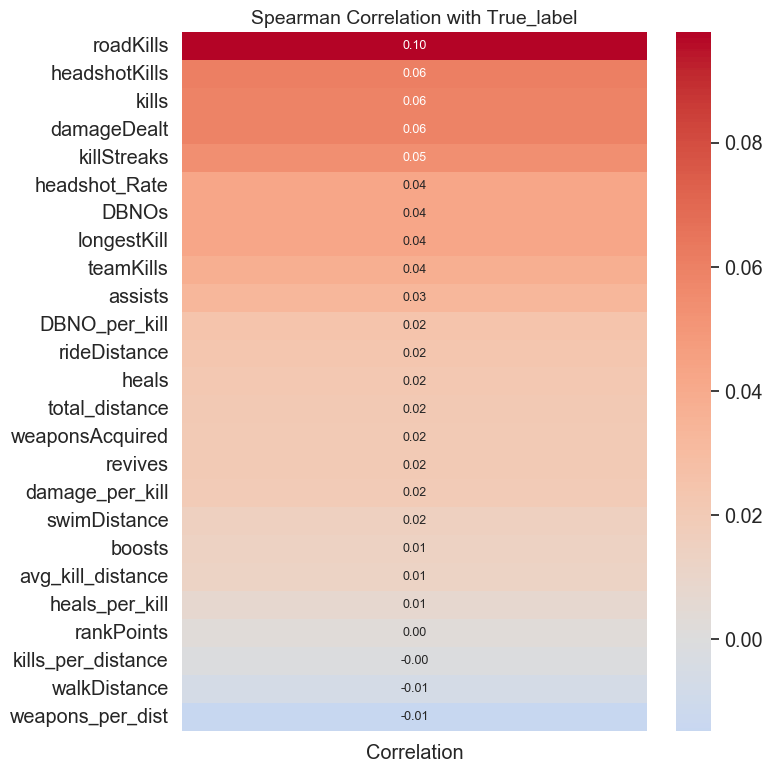

In [88]:
plot_df_V2 = raw_feature_V2.copy()
plot_df_V2['True_label'] = label
plot_corr(plot_df_V2, method='spearman')

In [133]:
METHODS = ['base', 'class_weight', 'smote']

results_V2 = {}
predictions_V2 = {}
models_dict_V2 = {}

for model_type in MODEL_TYPES:
    for method in METHODS:
        key = f"{model_type}_{method}"
        metrics, pred, pred_proba, model = train_evaluate(
            model_type, method, X_train_V2, y_train_V2, X_val_V2, y_val_V2, smote_ratio=0.05)
        results_V2[key]     = metrics
        predictions_V2[key] = (pred, pred_proba)
        models_dict_V2[key] = model
    print('-' * 40)

results_df_V2 = (pd.DataFrame(results_V2).T
                .astype(float)
                .round(4))
results_df_V2.index = pd.MultiIndex.from_tuples(
    [k.split('_', 1) for k in results_df_V2.index],
    names=['Model', 'Method'])

results_df_V2.style.format('{:.4f}')
results_df_V2

XGB | base : F1=0.5957
XGB | class_weight : F1=0.6393
XGB | smote | ratio=0.0500 : F1=0.6320
----------------------------------------
LGB | base : F1=0.4918
LGB | class_weight : F1=0.6252
LGB | smote | ratio=0.0500 : F1=0.6227
----------------------------------------
CAT | base : F1=0.5780
CAT | class_weight : F1=0.5747
CAT | smote | ratio=0.0500 : F1=0.6180
----------------------------------------


precision  recall  f1_score  pr_auc
Model Method                                           
xgb   base               0.90    0.44      0.60    0.74
      class_weight       0.69    0.59      0.64    0.70
      smote              0.78    0.53      0.63    0.70
lgb   base               0.50    0.48      0.49    0.46
      class_weight       0.53    0.77      0.63    0.74
      smote              0.80    0.51      0.62    0.73
cat   base               0.86    0.44      0.58    0.71
      class_weight       0.46    0.76      0.57    0.70
      smote              0.79    0.51      0.62    0.70

In [134]:
predictions_best_v1 = {}                                                                                                          
predictions_best_v2 = {}                                                                                                          
results_compare = {}                                                                                                              
models_best_v2 = {}                                                                                                    
                                                                                                                                
for method in ['smote', 'class_weight']:
    # Before FE (V1)
    metrics_v1, pred_v1, proba_v1, _ = train_evaluate(
        'xgb', method, X_train, y_train, X_val, y_val, smote_ratio=0.10)
    predictions_best_v1[f'xgb_{method}'] = (pred_v1, proba_v1)
    results_compare[f'V1 | {method}'] = metrics_v1

    # After FE (V2)
    metrics_v2, pred_v2, proba_v2, model = train_evaluate(
        'xgb', method, X_train_V2, y_train_V2, X_val_V2, y_val_V2, smote_ratio=0.10)
    predictions_best_v2[f'xgb_{method}'] = (pred_v2, proba_v2)
    results_compare[f'V2 | {method}'] = metrics_v2
    models_best_v2[f'xgb_{method}'] = model  # 추가

df_compare = (pd.DataFrame(results_compare).T
                .astype(float)
                .round(4))
df_compare.style.format('{:.4f}')

XGB | smote | ratio=0.1000 : F1=0.6261
XGB | smote | ratio=0.1000 : F1=0.6184
XGB | class_weight : F1=0.6017
XGB | class_weight : F1=0.6393


,precision,recall,f1_score,pr_auc
V1 | smote,0.8125,0.5092,0.6261,0.7032
V2 | smote,0.8044,0.5023,0.6184,0.7076
V1 | class_weight,0.6382,0.5691,0.6017,0.6715
V2 | class_weight,0.6946,0.5922,0.6393,0.6986


In [126]:
from sklearn.metrics import precision_recall_curve, auc                                                                           
                                                                                                                                
def plot_pr_compare(model_type, method,                                                                                           
                    predictions_v1, predictions_v2=None,                                                                          
                    y_val_v1=None, y_val_v2=None, ax=None):                                                                       
                                                                                                                                
    standalone = ax is None                                                                                                       
    if standalone:                                                                                                                
        fig, ax = plt.subplots(figsize=(8, 6))                                                                                  

    if predictions_v2 is None:
        # 단일
        key = f"{model_type}_{method}"
        _, pred_proba = predictions_v1[key]
        precision, recall, _ = precision_recall_curve(y_val_v1, pred_proba)
        pr_auc = auc(recall, precision)
        ax.plot(recall, precision, color='crimson', lw=2, label=f'PR AUC = {pr_auc:.4f}')
    else:
        # 비교
        for predictions, y_val, color, label_prefix in [
            (predictions_v1, y_val_v1, 'crimson',   'Before FE'),
            (predictions_v2, y_val_v2, 'steelblue', 'After FE'),
        ]:
            key = f"{model_type}_{method}"
            _, pred_proba = predictions[key]
            precision, recall, _ = precision_recall_curve(y_val, pred_proba)
            pr_auc = auc(recall, precision)
            ax.plot(recall, precision, color=color, lw=2,
                    label=f'{label_prefix}: {model_type.upper()} | {method} (AUC={pr_auc:.4f})')

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'PR Curve: {model_type.upper()} | {method}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_confusion(model_type, method, predictions, y_val, figsize=(8, 6), ax=None):
    key = f"{model_type}_{method}"
    pred, _ = predictions[key]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=0.7,
                xticklabels=['Normal', 'Hack'],
                yticklabels=['Normal', 'Hack'],
                ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix ({model_type.upper()} | {method})', fontsize=14)

    if standalone:
        plt.tight_layout()
        plt.show()

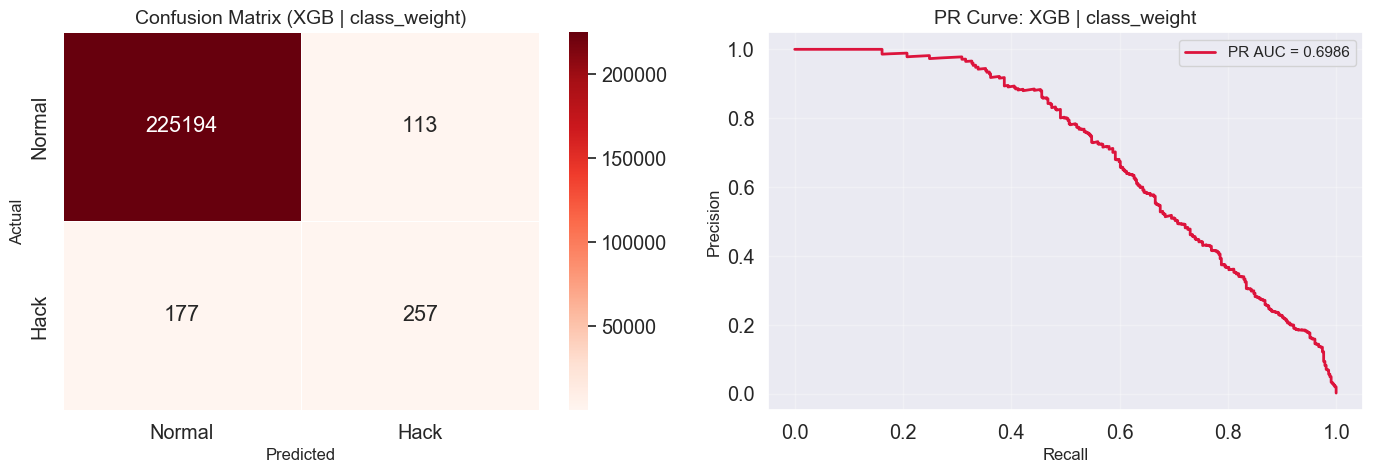

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                   
plot_confusion('xgb', 'class_weight', predictions_best_v2, y_val_V2, ax=axes[0])                                                  
plot_pr_compare('xgb', 'class_weight', predictions_best_v2, y_val_v1=y_val_V2, ax=axes[1])                                        
plt.tight_layout()                                                                                                                
plt.show()      

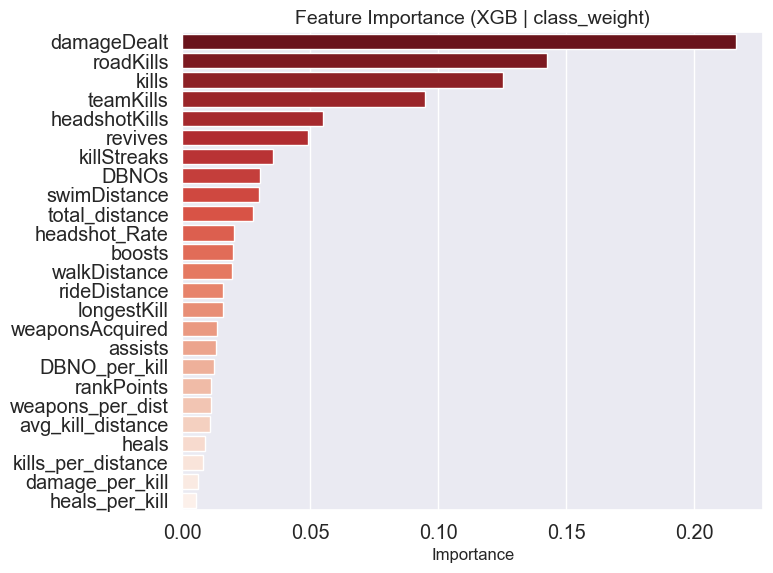

,feature,importance
0,damageDealt,0.22
1,roadKills,0.14
2,kills,0.13
3,teamKills,0.10
4,headshotKills,0.05
5,revives,0.05
6,killStreaks,0.04
7,DBNOs,0.03
8,swimDistance,0.03
9,total_distance,0.03


In [116]:
model = models_best_v2['xgb_class_weight']
imp_df = pd.DataFrame({
    'feature'   : X_train_V2.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=imp_df['importance'], y=imp_df['feature'], palette='Reds_r', ax=ax)
ax.set_title('Feature Importance (XGB | class_weight)', fontsize=14)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

imp_df

### Hyperparameter tuning

In [118]:
import optuna                                                                                                                     
from optuna.samplers import TPESampler         
from tqdm.auto import tqdm as tqdm_auto                                                                                   
optuna.logging.set_verbosity(optuna.logging.WARNING)                                                                              
                                                                                                                                
def objective(trial):
    params = {                                                                                                                    
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000),                                                     
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', 1.0, 100.0),
        'eval_metric'       : 'aucpr',
        'use_label_encoder' : False,
        'random_state'      : 42,
        'n_jobs'            : -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_V2, y_train_V2)
    pred = model.predict(X_val_V2)
    return f1_score(y_val_V2, pred)

def run_optuna(n_trials=100):
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

    with tqdm_auto(total=n_trials, desc='Optuna') as pbar:
        def callback(study, trial):
            pbar.set_postfix({'best_f1': f'{study.best_value:.4f}'})
            pbar.update(1)
        study.optimize(objective, n_trials=n_trials, callbacks=[callback])

    print(f'\nBest F1: {study.best_value:.4f}')
    print('Best params:')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    return study

In [119]:
study = run_optuna(n_trials=500)

Optuna:   0%|          | 0/500 [00:00<?, ?it/s]


Best F1: 0.6930
Best params:
  n_estimators: 964
  max_depth: 7
  learning_rate: 0.052256003424634094
  subsample: 0.7185523656980899
  colsample_bytree: 0.9125997890407086
  min_child_weight: 10
  reg_alpha: 0.00032222278446955945
  reg_lambda: 0.0179696968736333
  scale_pos_weight: 57.708524756655116


--------------------------------------------------------------------------------

In [120]:
# 최적 파라미터로 학습                                                                                          
best_model = xgb.XGBClassifier(                                                                                                   
    **study.best_params,                                                                                                          
    eval_metric='aucpr',                                                                                                      
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train_V2, y_train_V2)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9125997890407086
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [137]:
pred_test  = best_model.predict(X_test_V2)
proba_test = best_model.predict_proba(X_test_V2)[:, 1]
p_curve, r_curve, _ = precision_recall_curve(y_test_V2, proba_test)

final_metirc = pd.DataFrame([{
    'precision': round(precision_score(y_test_V2, pred_test), 4),
    'recall': round(recall_score(y_test_V2, pred_test), 4),
    'f1_score' : round(f1_score(y_test_V2, pred_test), 4),
    'pr_auc': round(auc(r_curve, p_curve), 4),
}], index=['XGB (tuned)'])
final_metirc

,precision,recall,f1_score,pr_auc
XGB (tuned),0.66,0.68,0.67,0.73


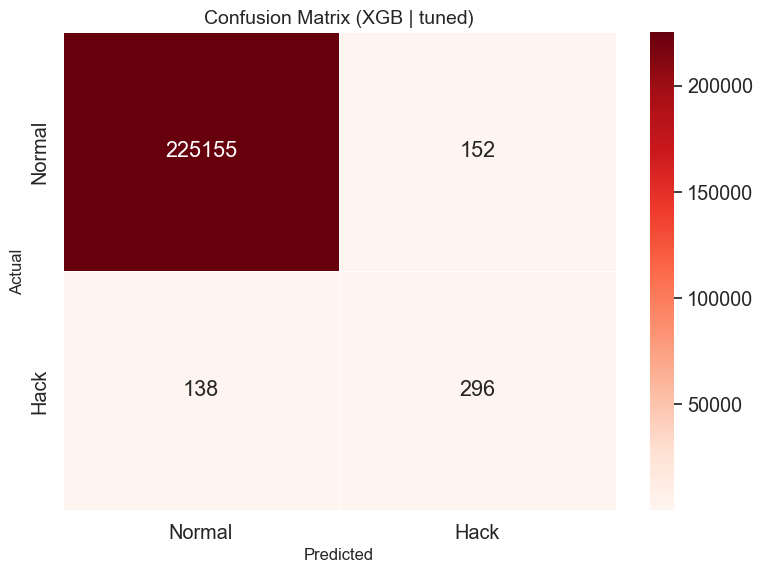

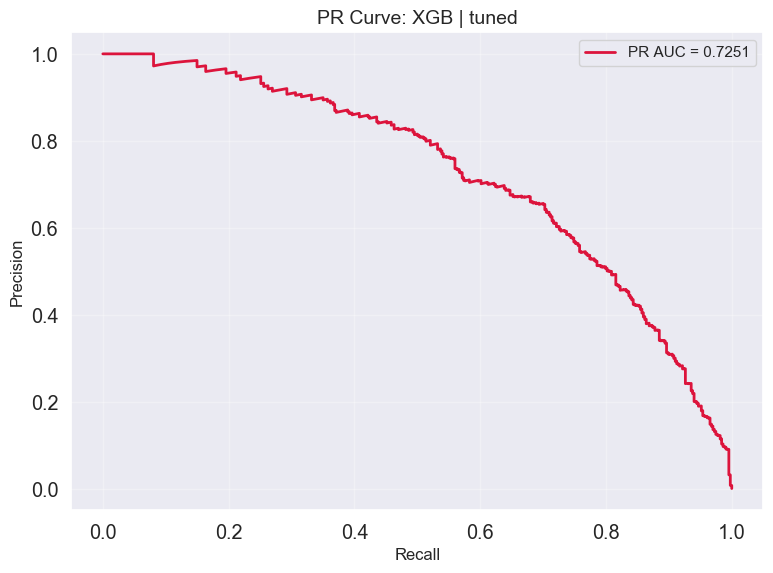

In [127]:
predictions_tuned = {'xgb_tuned': (pred_test, proba_test)}

# Confusion Matrix                                                                                             
plot_confusion('xgb', 'tuned', predictions_tuned, y_test_V2)
# PR Curve                                                                                                       
plot_pr_compare('xgb', 'tuned', predictions_tuned, y_val_v1=y_test_V2) 

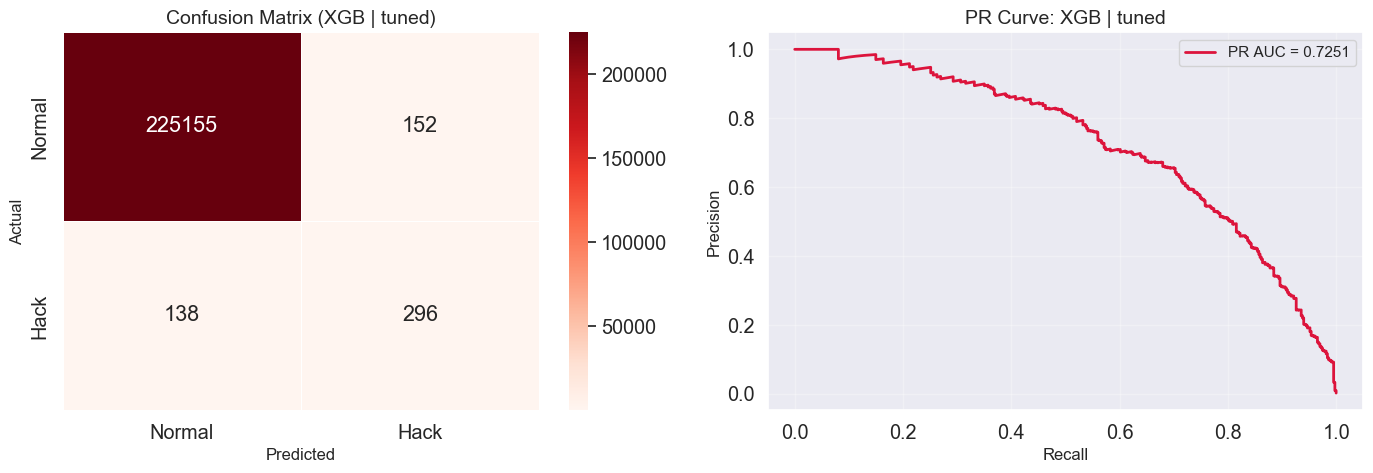

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                   
plot_confusion('xgb', 'tuned', predictions_tuned, y_test_V2, ax=axes[0])                                                          
plot_pr_compare('xgb', 'tuned', predictions_tuned, y_val_v1=y_test_V2, ax=axes[1])                                                
plt.tight_layout()                                                                                                                
plt.show()                                

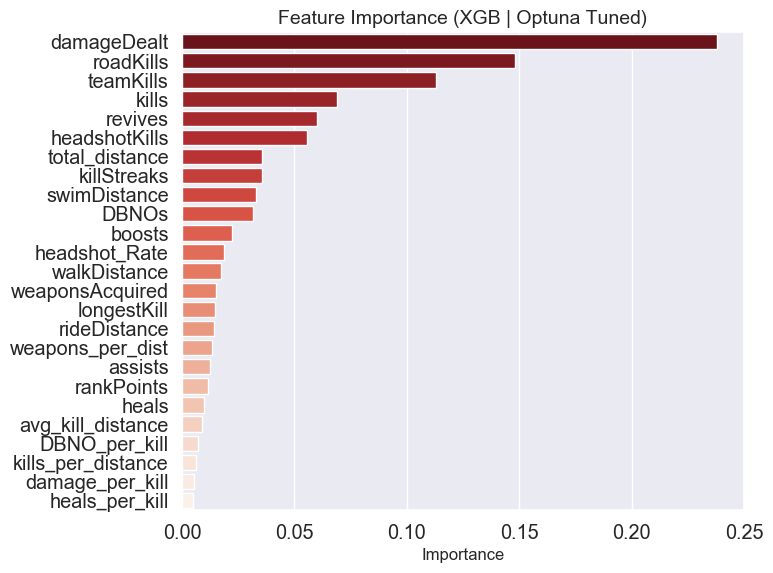

,feature,importance
0,damageDealt,0.24
1,roadKills,0.15
2,teamKills,0.11
3,kills,0.07
4,revives,0.06
5,headshotKills,0.06
6,total_distance,0.04
7,killStreaks,0.04
8,swimDistance,0.03
9,DBNOs,0.03


In [138]:
imp_df = pd.DataFrame({                                                                                          
    'feature'   : X_train_V2.columns,                                                                            
    'importance': best_model.feature_importances_                                                                
}).sort_values('importance', ascending=False).reset_index(drop=True)                                             
                                                                                                                
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=imp_df['importance'], y=imp_df['feature'], palette='Reds_r', ax=ax)
ax.set_title('Feature Importance (XGB | Optuna Tuned)', fontsize=14)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

imp_df

# 회고

- 비지도 학습 공통 이상치를 라벨로 정의하고, PSM, U-Test로 라벨 신뢰성을 통계적으로 검증하는 파이프라인을 직접 설계한 점이 핵심 성과                     
- Class Weight + Optuna 튜닝으로 Recall 0.68·F1 0.67·PR AUC 0.73 달성, 정상 유저 오탐율 **0.067%**             
- 실제 핵 유저 Ground Truth 라벨 부재로 비지도 학습 기반 라벨의 노이즈가 불가피하며, FN 32% 미탐지 한계 존재     
- 향후 threshold 최적화, 추가 행동 피처(연속 킬 패턴, 반응속도 등) 확보로 **Recall** 개선 가능